# Minimizzazione del makespan in un job-shop con PROC OPTMODEL


## Sintesi esecutiva

Una piccola cella di produzione discreta deve far passare quattro pezzi — una **Staffa**, una **Flangia**, un **Carter** e un **Albero** — attraverso una sequenza fissa di tre operazioni di lavorazione ciascuno, condividendo quattro macchine a capacità unitaria (**Sega**, **Fresa**, **Trapano**, **Rettifica**). Nessuna macchina può eseguire due operazioni contemporaneamente, e le operazioni di ciascun pezzo devono seguire il loro ordine tecnologico. Formuliamo la pianificazione che minimizza il makespan come programma a numeri interi misti in **PROC OPTMODEL** — variabili di tempo di inizio, vincoli di precedenza fine-inizio e vincoli disgiuntivi (big-*M*) di non sovrapposizione tra ogni coppia di operazioni che condividono una macchina — e la risolviamo fino all'ottimalità dimostrata.

Il risolutore MILP restituisce un **makespan ottimo di 120 minuti** (`Solution Status = Optimal`, `Objective Value = 120`). La pianificazione risultante compatta tutte e dodici le operazioni in modo che ogni macchina lavori al massimo un pezzo alla volta e ogni pezzo rispetti l'ordine tecnologico richiesto delle sue operazioni. Due operazioni terminano esattamente al minuto 120 — la rettifica della Staffa e la fresatura del Carter — quindi sia la macchina Rettifica sia la macchina Fresa si trovano sul percorso critico che fissa la durata della pianificazione.

## Fonti dei dati

Tutti i dati sono definiti all'interno del notebook — nessun file esterno o rete.

| Dataset | Righe | Variabili chiave | Descrizione |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Una riga per operazione (4 pezzi × 3 operazioni). `machine` (1–4) è la macchina di cui l'operazione ha bisogno; `dur` è il suo tempo di lavorazione in minuti; `jobname`/`mname` sono etichette leggibili di pezzo e macchina. |
| `sched` | 12 | `op`, `start`, `finish` | Output di OPTMODEL: il minuto ottimo di inizio e fine di ogni operazione. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` unito ai tempi risolti, ordinato per macchina e poi per inizio — la pianificazione leggibile. |
| `mk` | 1 | `makespan` | Il makespan realizzato (tempo di fine più tardivo). |

## Il problema di scheduling

In un **job shop**, diversi pezzi ("job") passano ciascuno attraverso una sequenza fissa di operazioni, e ogni operazione viene eseguita su una macchina specifica. Due operazioni non possono occupare la stessa macchina nello stesso momento (le macchine sono risorse *unarie*), e all'interno di un pezzo le operazioni devono rispettare il loro ordine tecnologico. Il pianificatore vuole tempi di inizio per ogni operazione che onorino entrambe le regole mantenendo la durata totale della pianificazione — il **makespan** — la più piccola possibile.

Questo è un classico problema di scheduling disgiuntivo. Lo modelliamo come un programma a numeri interi misti:

- un **tempo di inizio** `s[o]` continuo-ma-intero per ogni operazione, e una variabile makespan `Cmax`;
- **precedenza**: l'operazione *k+1* di un pezzo inizia non prima che l'operazione *k* termini;
- **capacità disgiuntiva della macchina**: per ogni coppia di operazioni che condividono una macchina, una binaria `y` decide quale va per prima, e un termine big-*M* disattiva l'ordinamento inattivo — così le due operazioni non possono mai sovrapporsi;
- **obiettivo**: minimizzare `Cmax`, che è forzato a essere almeno pari al tempo di fine di ogni operazione.

PROC OPTMODEL è la procedura di modellazione algebrica di SAS/OR; il suo risolutore MILP trova la pianificazione più breve *dimostrabilmente ottima*.

> **Una nota su PROC CLP.** SAS offre anche PROC CLP, un motore di > programmazione a logica dei vincoli con sintassi di scheduling dedicata (attività, > risorse, precedenza). La formulazione MILP di OPTMODEL qui risolve il > problema identico e restituisce un certificato di ottimalità, cosa che la > ricerca di ammissibilità di CLP non fa.

## Passo 1 — Definire l'istanza del job shop

Quattro pezzi, tre operazioni ciascuno, su quattro macchine. Ogni riga fissa la macchina di cui un'operazione ha bisogno e il suo tempo di lavorazione in minuti. Le operazioni di un pezzo sono elencate in ordine tecnologico (`opnum` 1, 2, 3).

In [1]:
DATI jobshop;
    LUNGHEZZA jobname $10 mname $10;
    INGRESSO op job opnum machine dur jobname $ mname $;
    DATALINES;
1  1 1 1 25 Staffa   Sega
2  1 2 3 40 Staffa   Trapano
3  1 3 4 20 Staffa   Rettifica
4  2 1 2 35 Flangia  Fresa
5  2 2 3 25 Flangia  Trapano
6  2 3 1 15 Flangia  Sega
7  3 1 3 30 Carter   Trapano
8  3 2 1 20 Carter   Sega
9  3 3 2 45 Carter   Fresa
10 4 1 1 20 Albero   Sega
11 4 2 2 30 Albero   Fresa
12 4 3 4 25 Albero   Rettifica
;
ESEGUIRE;

PROCEDURA STAMPARE DATI=jobshop noobs ETICHETTA;
    TITOLO "Istanza job shop: 4 pezzi, 3 operazioni ciascuno, 4 macchine";
    VARIABILE op jobname opnum mname dur;
    ETICHETTA op="Op." jobname="Pezzo" opnum="N. op."
              mname="Macchina" dur="Durata (min)";
ESEGUIRE;

                              Istanza job shop: 4 pezzi, 3 operazioni ciascuno, 4 macchine                              

Op.    Pezzo  N. op.   Macchina  Durata (min)
  1  Staffa        1  Sega                 25
  2  Staffa        2  Trapano              40
  3  Staffa        3  Rettifica            20
  4  Flangia       1  Fresa                35
  5  Flangia       2  Trapano              25
  6  Flangia       3  Sega                 15
  7  Carter        1  Trapano              30
  8  Carter        2  Sega                 20
  9  Carter        3  Fresa                45
 10  Albero        1  Sega                 20
 11  Albero        2  Fresa                30
 12  Albero        3  Rettifica            25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Passo 2 — Risolvere la pianificazione che minimizza il makespan con PROC OPTMODEL

OPTMODEL legge l'istanza, costruisce le variabili di tempo di inizio e di ordinamento, pone i vincoli di precedenza e disgiuntivi, e minimizza il makespan con il suo risolutore MILP. L'orizzonte big-*M* `H` è il contenuto totale di lavoro — un limite superiore sicuro per qualsiasi tempo di inizio. Il risolutore riporta l'obiettivo **ottimo**; scriviamo i tempi di inizio e fine scelti in `sched`.

In [2]:
PROCEDURA optmodel;
    IMPOSTARE OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DATI jobshop INTO OPS=[op] job opnum machine dur;

    /* un orizzonte big-M sicuro = contenuto totale di lavoro */
    num H = sum{o IN OPS} dur[o];

    VARIABILE s{OPS} >= 0 integer;     /* tempo di inizio operazione (minuti) */
    VARIABILE Cmax >= 0;               /* makespan */

    /* ordine tecnologico: l'op k+1 inizia dopo la fine dell'op k */
    con prec{a IN OPS, b IN OPS:
             job[a] = job[b] E_LOG opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* il makespan domina il tempo di fine di ogni operazione */
    con span{o IN OPS}: Cmax >= s[o] + dur[o];

    /* capacità disgiuntiva della macchina: per ogni coppia di operazioni che
       condividono una macchina, la binaria y fissa l'ordine; big-M rilassa l'altro */
    VARIABILE y{a IN OPS, b IN OPS:
          a < b E_LOG machine[a] = machine[b]} binary;
    con seqAB{a IN OPS, b IN OPS:
              a < b E_LOG machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a IN OPS, b IN OPS:
              a < b E_LOG machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o IN OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CREARE DATI sched FROM
        [op]={o IN OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                              Istanza job shop: 4 pezzi, 3 operazioni ciascuno, 4 macchine                              


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Passo 3 — Assemblare la pianificazione leggibile

Uniamo i tempi risolti alle etichette di pezzo e macchina, ordiniamo per macchina e poi per tempo di inizio, e stampiamo la pianificazione. Il makespan è il tempo di fine più grande tra tutte le operazioni.

In [3]:
PROCEDURA ORDINARE DATI=jobshop out=jobs2; PER op; ESEGUIRE;
PROCEDURA ORDINARE DATI=sched   out=sol;   PER op; ESEGUIRE;

DATI schedule;
    UNIRE jobs2 sol;
    PER op;
ESEGUIRE;

PROCEDURA ORDINARE DATI=schedule; PER mname START; ESEGUIRE;

PROCEDURA STAMPARE DATI=schedule noobs ETICHETTA;
    TITOLO "Pianificazione ottima: inizio / fine (minuti) di ogni operazione";
    VARIABILE jobname opnum mname dur START FINISH;
    ETICHETTA jobname="Pezzo" opnum="N. op." mname="Macchina"
              dur="Durata (min)" START="Inizio (min)" FINISH="Fine (min)";
ESEGUIRE;

PROCEDURA MEDIE DATI=schedule MAX NOPRINT;
    VARIABILE FINISH;
    USCITA out=mk(RIMUOVERE=_type_ _freq_) MAX=makespan;
ESEGUIRE;

PROCEDURA STAMPARE DATI=mk noobs ETICHETTA;
    TITOLO "Makespan minimo (fine dell'operazione più tardiva, minuti)";
    ETICHETTA makespan="Makespan (min)";
ESEGUIRE;

                            Pianificazione ottima: inizio / fine (minuti) di ogni operazione                            

  Pezzo  N. op.   Macchina  Durata (min)  Inizio (min)  Fine (min)
Flangia       1  Fresa                35             0          35
Albero        2  Fresa                30            35          65
Carter        3  Fresa                45            75         120
Albero        3  Rettifica            25            65          90
Staffa        3  Rettifica            20           100         120
Albero        1  Sega                 20             0          20
Staffa        1  Sega                 25            20          45
Carter        2  Sega                 20            45          65
Flangia       3  Sega                 15            65          80
Carter        1  Trapano              30             0          30
Flangia       2  Trapano              25            35          60
Staffa        2  Trapano              40            60         100

      


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Passo 4 — Visualizzare la pianificazione

Assegniamo a ogni operazione uno **slot** ordinale (ordinato per macchina, poi per inizio) e disegniamo la sua finestra temporale come una barra fluttuante: la barra si estende dal minuto di inizio dell'operazione al suo minuto di fine. Gli slot 1–3 sono la Fresa, i 4–5 la Rettifica, i 6–9 la Sega e i 10–12 il Trapano. La tabella subito sotto nomina il pezzo in ciascuno slot, così che grafico e tabella si leggano insieme. Le barre sulla stessa macchina non si sovrappongono mai nel tempo — il vincolo disgiuntivo reso visibile.

                       Pianificazione per slot (l'ordine degli slot corrisponde al grafico sotto)                       

Slot   Macchina    Pezzo  Inizio (min)  Fine (min)
   1  Fresa      Flangia             0          35
   2  Fresa      Albero             35          65
   3  Fresa      Carter             75         120
   4  Rettifica  Albero             65          90
   5  Rettifica  Staffa            100         120
   6  Sega       Albero              0          20
   7  Sega       Staffa             20          45
   8  Sega       Carter             45          65
   9  Sega       Flangia            65          80
  10  Trapano    Carter              0          30
  11  Trapano    Flangia            35          60
  12  Trapano    Staffa             60         100

                       Pianificazione per slot (l'ordine degli slot corrisponde al grafico sotto)                       




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


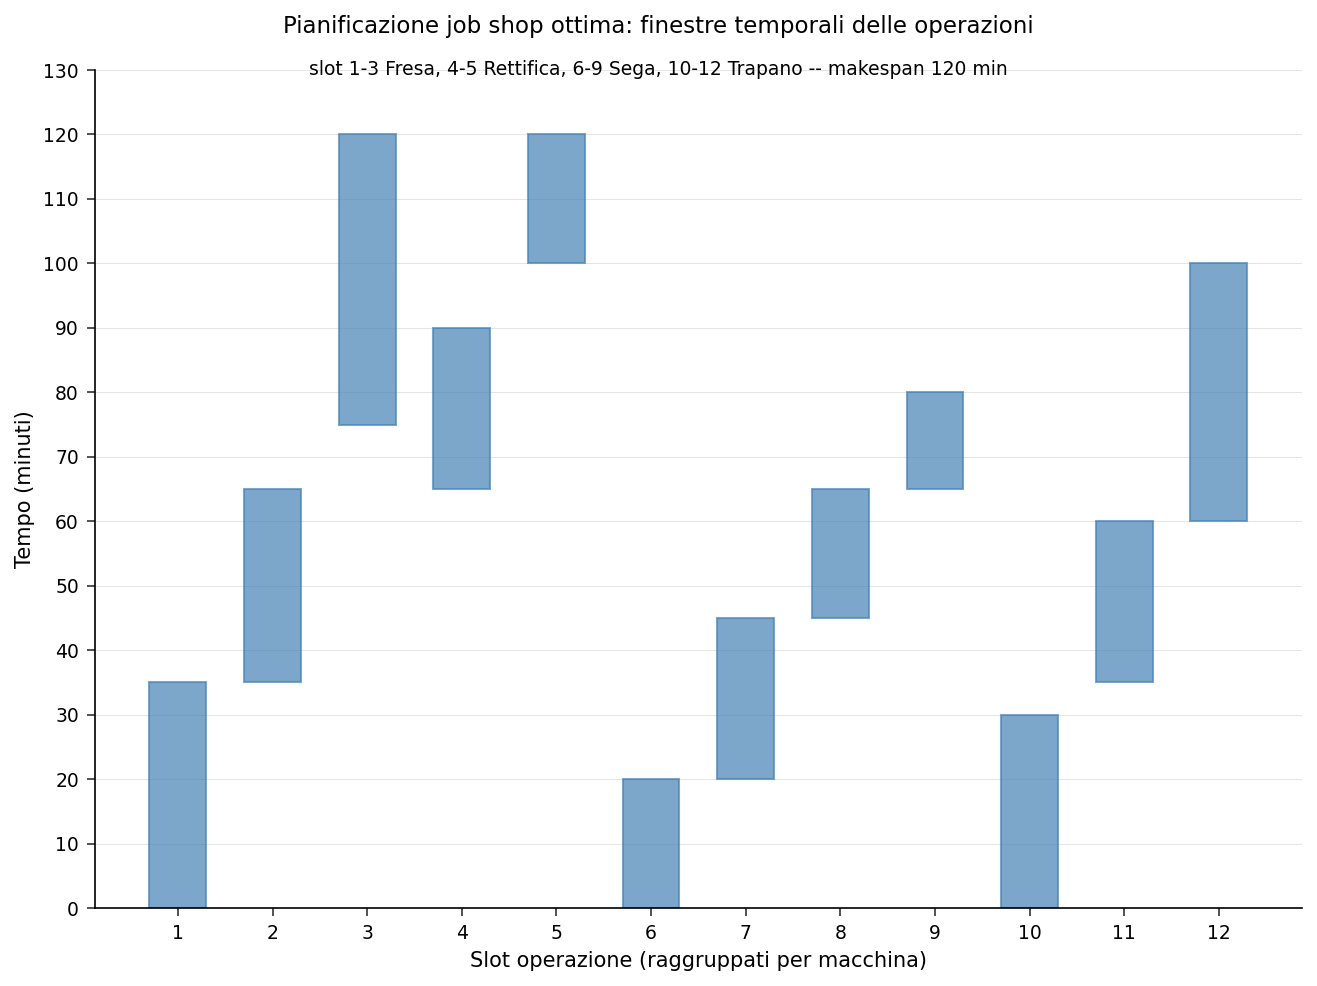

In [4]:
DATI ganttdata;
    IMPOSTARE schedule;
    slot + 1;
ESEGUIRE;

PROCEDURA STAMPARE DATI=ganttdata noobs ETICHETTA;
    TITOLO "Pianificazione per slot (l'ordine degli slot corrisponde al grafico sotto)";
    VARIABILE slot mname jobname START FINISH;
    ETICHETTA slot="Slot" mname="Macchina" jobname="Pezzo"
              START="Inizio (min)" FINISH="Fine (min)";
ESEGUIRE;

PROCEDURA SGPLOT DATI=ganttdata noautolegend;
    TITOLO "Pianificazione job shop ottima: finestre temporali delle operazioni";
    title2 "slot 1-3 Fresa, 4-5 Rettifica, 6-9 Sega, 10-12 Trapano -- makespan 120 min";
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ETICHETTA='Slot operazione (raggruppati per macchina)' integer
          VALUES=(1 FINO_A 12 PER 1);
    YAXIS ETICHETTA='Tempo (minuti)' grid VALUES=(0 FINO_A 130 PER 10);
ESEGUIRE;
TITOLO;

## Interpretazione dei risultati

- **Ottimalità.** Il risolutore MILP ha restituito `Solution Status = Optimal` con `Objective Value = 120`, quindi **120 minuti è il makespan più breve dimostrabilmente possibile** per questa istanza — nessuna pianificazione può terminare prima. Questo certificato è ciò che la formulazione di programmazione matematica offre rispetto a una pura ricerca di ammissibilità.

- **La pianificazione onora ogni vincolo.** Leggendo la tabella per macchina, nessuna coppia di operazioni sulla stessa macchina si sovrappone (ad es. sulla Sega: Albero 0–20, Staffa 20–45, Carter 45–65, Flangia 65–80), e ogni pezzo scorre in ordine tecnologico (ad es. Carter: Trapano 0–30, poi Sega 45–65, poi Fresa 75–120). Il grafico a barre fluttuanti mostra lo stesso: all'interno della banda di slot di ogni macchina le finestre temporali si affiancano senza collisioni.

- **Cosa determina la durata della pianificazione.** Due operazioni terminano esattamente al minuto 120 — la Rettifica della Staffa (slot 5) e la Fresa del Carter (slot 3). Entrambe toccano il makespan, quindi le macchine Rettifica e Fresa si trovano sul percorso critico; ridurre ulteriormente il makespan richiederebbe di cambiare l'istanza stessa (operazioni più veloci, una macchina in più o precedenze rilassate), non semplicemente ri-sequenziare.

- **Come scala.** La formulazione cresce naturalmente: aggiungere una macchina come un altro valore di `machine`, aggiungere pezzi come altre righe di `jobshop`, o modellare date di rilascio e di scadenza limitando `s[o]` e aggiungendo vincoli di scadenza. Consentire a una macchina di eseguire più job contemporaneamente (capacità >1) sostituisce la disgiunzione a coppie con un vincolo di risorsa cumulativa. Lo stesso MILP di OPTMODEL gestisce poi regole di officina più ricche senza cambiare il risolutore.